# Lab 08 — Genetic Algorithms: Regression and Reproducibility

**Worked Python solution.** We implement a real-valued genetic algorithm (GA), verify it on a simple one-dimensional objective, then fit medical-cost regression coefficients over 10 independent random seeds. Ordinary least squares is the exact baseline for this unconstrained linear problem.

In [1]:
from pathlib import Path
import sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore", category=FutureWarning)

def find_project_root():
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "all_datasets").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the course project.")
ROOT=find_project_root()
print("Project root:",ROOT)

import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

RESULTS=ROOT/"results"/"lab08"; RESULTS.mkdir(parents=True,exist_ok=True)
df=pd.read_csv(ROOT/"all_datasets"/"lab08-insurance.csv")
X=df[["age","bmi","children"]].copy(); X["smoker"]=(df.smoker=="yes").astype(float); y=df.charges.to_numpy(float)
indices=np.arange(len(df)); train_idx,test_idx=train_test_split(indices,test_size=.20,random_state=42)
pd.DataFrame({"row_id":indices,"split":np.where(np.isin(indices,test_idx),"test","train")}).to_csv(RESULTS/"split.csv",index=False)
scaler=StandardScaler().fit(X.iloc[train_idx]); Xtrain=scaler.transform(X.iloc[train_idx]); Xtest=scaler.transform(X.iloc[test_idx]); ytrain=y[train_idx]; ytest=y[test_idx]
print({"rows":len(df),"train":len(train_idx),"test":len(test_idx)})

Project root: /mnt/data/ai_course_final/ARTIFICIAL INTELLIGENCE


{'rows': 1338, 'train': 1070, 'test': 268}


## 1. Verify the evolutionary loop on \(f(x)=(x-3)^2\)

In [2]:
def ga_scalar(seed=42,pop_size=40,generations=80):
    rng=np.random.default_rng(seed); pop=rng.uniform(-10,10,pop_size)
    for _ in range(generations):
        fit=(pop-3)**2; elite=pop[np.argsort(fit)[:2]].copy(); cand=rng.integers(0,pop_size,size=(pop_size,3)); parents=pop[cand[np.arange(pop_size),fit[cand].argmin(axis=1)]]; rng.shuffle(parents)
        a,b=parents[0::2],parents[1::2]; alpha=rng.random(len(a)); children=np.r_[alpha*a+(1-alpha)*b,alpha*b+(1-alpha)*a][:pop_size-2]; children+=rng.normal(0,.15,len(children)); pop=np.r_[elite,children]
    best=pop[np.argmin((pop-3)**2)]; return best,(best-3)**2
xbest,fbest=ga_scalar(); print(f"Best x={xbest:.6f}; f(x)={fbest:.8f}")

Best x=3.000141; f(x)=0.00000002


## 2. Real-valued GA for regression coefficients

In [3]:
def run_ga(seed,pop_size=100,generations=160,mutation_rate=.15,mutation_scale=.25):
    rng=np.random.default_rng(seed); d=Xtrain.shape[1]+1
    pop=rng.normal(0,5000,size=(pop_size,d)); pop[:,0]+=ytrain.mean()
    def mse_population(P):
        pred=P[:,0,None]+P[:,1:]@Xtrain.T
        return ((pred-ytrain[None,:])**2).mean(axis=1)
    best=None; best_mse=np.inf; history=[]; t0=time.perf_counter()
    for _ in range(generations):
        fit=mse_population(pop); i=int(fit.argmin())
        if fit[i]<best_mse: best_mse=float(fit[i]); best=pop[i].copy()
        history.append(best_mse)
        elite=pop[np.argsort(fit)[:4]].copy()
        tournaments=rng.integers(0,pop_size,size=(pop_size,3)); winners=tournaments[np.arange(pop_size),fit[tournaments].argmin(axis=1)]; parents=pop[winners]; rng.shuffle(parents)
        a,b=parents[0::2],parents[1::2]; alpha=rng.uniform(-.1,1.1,size=(len(a),1)); children=np.vstack([alpha*a+(1-alpha)*b,alpha*b+(1-alpha)*a])[:pop_size-4]
        mask=rng.random(children.shape)<mutation_rate; scales=np.r_[2000,np.repeat(1000,d-1)]; children+=mask*rng.normal(0,mutation_scale,size=children.shape)*scales
        pop=np.vstack([elite,children])
    runtime=time.perf_counter()-t0; test_pred=best[0]+Xtest@best[1:]
    return {"seed":seed,"train_rmse":best_mse**.5,"test_rmse":mean_squared_error(ytest,test_pred)**.5,"runtime_s":runtime,"coefficients":best,"history":np.array(history)}

In [4]:
runs=[]
for seed in range(1,11): runs.append(run_ga(seed))
run_table=pd.DataFrame([{k:v for k,v in r.items() if k not in ["coefficients","history"]} for r in runs]); run_table.to_csv(RESULTS/"ga_10_runs.csv",index=False); display(run_table.round(3))
print("Median GA test RMSE:",round(run_table.test_rmse.median(),2))
print("SD across seeds:",round(run_table.test_rmse.std(ddof=1),4))

,seed,train_rmse,test_rmse,runtime_s
0,1,6113.068,5829.374,0.104
1,2,6113.068,5829.379,0.115
2,3,6113.068,5829.377,0.128
3,4,6113.068,5829.379,0.123
4,5,6113.068,5829.377,0.102
5,6,6113.068,5829.383,0.110
6,7,6113.068,5829.380,0.088
7,8,6113.068,5829.378,0.095
8,9,6113.068,5829.374,0.113
9,10,6113.068,5829.378,0.122


Median GA test RMSE: 5829.38
SD across seeds: 0.0027


## 3. Ordinary least-squares baseline

OLS test RMSE: 5829.38
OLS coefficients on standardized inputs: {'age': np.float64(3616.32), 'bmi': np.float64(1978.42), 'children': np.float64(519.23), 'smoker': np.float64(9559.32)}


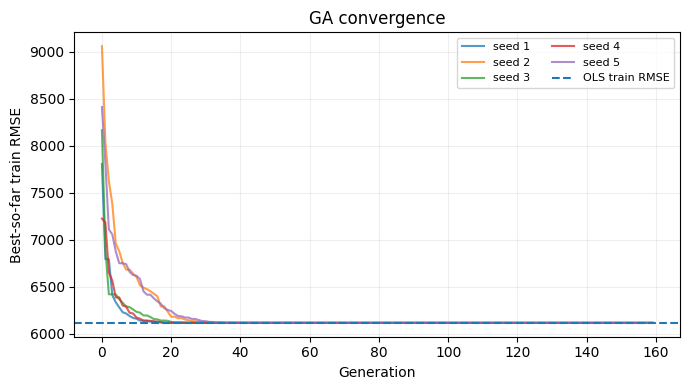

In [5]:
ols=LinearRegression().fit(Xtrain,ytrain); ols_pred=ols.predict(Xtest); ols_rmse=mean_squared_error(ytest,ols_pred)**.5
print("OLS test RMSE:",round(ols_rmse,2)); print("OLS coefficients on standardized inputs:",dict(zip(["age","bmi","children","smoker"],ols.coef_.round(2))))

fig,ax=plt.subplots(figsize=(7,4))
for r in runs[:5]: ax.plot(np.sqrt(r["history"]),alpha=.75,label=f"seed {r['seed']}")
ax.axhline(mean_squared_error(ytrain,ols.predict(Xtrain))**.5,linestyle="--",label="OLS train RMSE")
ax.set(xlabel="Generation",ylabel="Best-so-far train RMSE",title="GA convergence"); ax.legend(ncol=2,fontsize=8); ax.grid(alpha=.2); fig.tight_layout(); fig.savefig(RESULTS/"convergence.png",dpi=160); plt.show()

## 4. Sensitivity test: population 100 → 40

In [6]:
small=[run_ga(seed,pop_size=40) for seed in range(1,11)]
small_table=pd.DataFrame([{k:v for k,v in r.items() if k not in ["coefficients","history"]} for r in small]); small_table.to_csv(RESULTS/"ga_sensitivity_pop40.csv",index=False)
summary=pd.DataFrame([
    {"method":"GA pop=100","median_test_rmse":run_table.test_rmse.median(),"sd_test_rmse":run_table.test_rmse.std(ddof=1),"median_runtime_s":run_table.runtime_s.median()},
    {"method":"GA pop=40","median_test_rmse":small_table.test_rmse.median(),"sd_test_rmse":small_table.test_rmse.std(ddof=1),"median_runtime_s":small_table.runtime_s.median()},
    {"method":"OLS","median_test_rmse":ols_rmse,"sd_test_rmse":0.0,"median_runtime_s":np.nan},
]); summary.to_csv(RESULTS/"summary.csv",index=False); display(summary.round(4))

,method,median_test_rmse,sd_test_rmse,median_runtime_s
0,GA pop=100,5829.3782,0.0027,0.1116
1,GA pop=40,5829.3779,0.0203,0.0430
2,OLS,5829.3785,0.0000,NaN


## Worked interpretation

For an unconstrained linear least-squares problem, OLS is the correct baseline because it has a direct deterministic solution. The GA can approach essentially the same coefficient optimum, but it requires many objective evaluations and introduces seed-dependent computation. Reducing population size cuts runtime without materially changing RMSE once the search is already converging well.

A GA becomes more defensible when the objective is non-differentiable, discrete/mixed, multi-modal, constrained in awkward ways, or includes business rules that prevent a closed-form optimizer. **The lesson is not “GA beats regression”; it is to match the optimizer to the structure of the problem.**